# Tutorial: Research Stop Loss

This notebook shows how to place the stop-loss execution engine between a strategy signal and `perf()`.

`stop_loss()` returns the same transaction-frame schema as `no_stop()`, so the final performance call is unchanged.

## Data source

The examples use continuous NQ futures from the local Arctic store:

```python
store = ArcticStore("contfutures")
df = store.store.read("NQ")
df = df.loc["2023-06-01":]
```

Any other OHLC dataframe can be substituted. The examples expect at least `open`, `high`, `low`, and `close`; `volume` and `barCount` are used when available.

In [1]:
import numpy as np
import pandas as pd

from haymaker.datastore import ArcticStore

store = ArcticStore("contfutures")
item = store.store.read("NQ")
df = item.data if hasattr(item, "data") else item
df = df.loc["2023-06-01":].copy()
df = df.sort_index()

df.head()

Library created, but couldn't enable sharding: no such command: 'enablesharding', full error: {'ok': 0.0, 'errmsg': "no such command: 'enablesharding'", 'code': 59, 'codeName': 'CommandNotFound'}. This is OK if you're not 'admin'


,open,high,low,close,volume,average,barCount
date,,,,,,,
2023-06-01 00:00:00+00:00,17073.25,17073.50,17070.75,17072.75,81.0,17072.125,65
2023-06-01 00:00:30+00:00,17072.25,17072.50,17071.25,17071.25,13.0,17071.925,10
2023-06-01 00:01:00+00:00,17071.00,17072.75,17067.75,17070.00,82.0,17069.975,53
2023-06-01 00:01:30+00:00,17069.75,17070.25,17068.25,17069.75,61.0,17069.050,48
2023-06-01 00:02:00+00:00,17070.50,17073.50,17070.50,17072.75,59.0,17072.375,45


In [2]:
required = ["open", "high", "low", "close"]
optional = [column for column in ["volume", "barCount", "average"] if column in df.columns]
df = df[required + optional].dropna().copy()

# The NQ 30-second slice is large. Keep the tutorial responsive; set this
# to None if you want to run every example on the full history.
max_rows = 100_000
if max_rows is not None and len(df) > max_rows:
    df = df.tail(max_rows).copy()

df.tail()

,open,high,low,close,volume,barCount,average
date,,,,,,,
2026-03-24 08:32:30+00:00,24405.00,24407.25,24395.50,24398.50,100.0,65,24403.250
2026-03-24 08:33:00+00:00,24401.50,24404.75,24395.50,24397.75,57.0,46,24400.575
2026-03-24 08:33:30+00:00,24396.25,24402.25,24385.25,24387.25,78.0,60,24394.300
2026-03-24 08:34:00+00:00,24387.75,24395.75,24387.75,24391.75,39.0,35,24392.900
2026-03-24 08:34:30+00:00,24391.25,24399.25,24391.25,24396.00,31.0,26,24395.875


## Strategy input

In [3]:
fast_window = 20
slow_window = 80

strategy = df.copy()
strategy["fast_ma"] = strategy["close"].rolling(fast_window).mean()
strategy["slow_ma"] = strategy["close"].rolling(slow_window).mean()

raw_signal = pd.Series(
    np.where(strategy["fast_ma"] > strategy["slow_ma"], 1, -1),
    index=strategy.index,
)
raw_signal = raw_signal.where(strategy["slow_ma"].notna(), 0)

# The signal uses the current bar close, so shift it before executing at
# the next bar open.
strategy["position"] = raw_signal.shift().fillna(0).astype(int)

strategy[["close", "fast_ma", "slow_ma", "position"]].tail()

,close,fast_ma,slow_ma,position
date,,,,
2026-03-24 08:32:30+00:00,24398.50,24405.0000,24449.078125,-1
2026-03-24 08:33:00+00:00,24397.75,24403.3375,24448.237500,-1
2026-03-24 08:33:30+00:00,24387.25,24401.4375,24447.331250,-1
2026-03-24 08:34:00+00:00,24391.75,24399.9500,24446.440625,-1
2026-03-24 08:34:30+00:00,24396.00,24398.9500,24445.706250,-1


## Stop distance

`distance` must already be aligned to the dataframe index and expressed in price units. This example uses a simple ATR-style estimate.

In [4]:
def atr(data: pd.DataFrame, window: int = 20) -> pd.Series:
    previous_close = data["close"].shift()
    true_range = pd.concat(
        [
            data["high"] - data["low"],
            (data["high"] - previous_close).abs(),
            (data["low"] - previous_close).abs(),
        ],
        axis=1,
    ).max(axis=1)
    return true_range.rolling(window).mean().bfill()

stop_distance = 2 * atr(strategy, 20)
stop_distance.tail()

date
2026-03-24 08:32:30+00:00    23.550
2026-03-24 08:33:00+00:00    23.675
2026-03-24 08:33:30+00:00    24.275
2026-03-24 08:34:00+00:00    24.175
2026-03-24 08:34:30+00:00    23.750
dtype: float64

## Compare stop configurations

Key parameters:

- `mode="trail"` trails the stop with favorable price movement.
- `mode="fixed"` keeps the stop fixed from entry.
- `tp_multiple` adds a take-profit at `tp_multiple * distance`.
- `time_stop` closes a position after a fixed number of processed bars.

In [5]:
from haymaker.research.backtester import no_stop, perf
from haymaker.research.stop import stop_loss
from haymaker.research.result_analysis import paths

configs = {
    "no_stop": None,
    "trail": {"mode": "trail"},
    "fixed": {"mode": "fixed"},
    "trail_tp_3x": {"mode": "trail", "tp_multiple": 3},
    "trail_time_stop": {"mode": "trail", "time_stop": 120},
}

results = {}
for name, kwargs in configs.items():
    if kwargs is None:
        tx = no_stop(strategy, price_column="open")
    else:
        tx = stop_loss(
            strategy,
            distance=stop_distance,
            price_column="open",
            **kwargs,
        )
    results[name] = perf(tx, slippage=1)

pd.DataFrame({name: result.stats for name, result in results.items()}).T

,total_return,max_drawdown,fixed_max_drawdown,max_drawdown_pnl,median_21d_drawdown,fixed_median_21d_drawdown,fixed_annual_return,fixed_annual_volatility,fixed_sharpe_ratio,fixed_sortino_ratio,...,avg_duration,median_duration,p90_duration,max_duration,time_in_market,best_trade,worst_trade,net_pnl_ex_best,best_trade_share,top5_trade_share
no_stop,-0.200217,-0.252346,-0.258719,-6674.5,-0.121962,-0.122421,-1.363641,0.229655,-5.937785,-6.234545,...,0 days 00:43:14.015513126,0 days 00:23:30,0 days 01:09:45,2 days 02:25:00,0.9992,640.75,-319.75,-5806.0,0.02763,0.083137
trail,-0.08878,-0.109969,-0.109969,-2837.0,-0.051262,-0.048266,-0.604665,0.093665,-6.455598,-7.640083,...,0 days 00:06:08.860381861,0 days 00:03:00,0 days 00:09:30,2 days 01:51:30,0.16203,482.7,-61.975,-2773.075,0.053734,0.107746
fixed,-0.163863,-0.202518,-0.206682,-5332.025,-0.091777,-0.086456,-1.116039,0.160406,-6.957569,-6.868373,...,0 days 00:25:04.134844868,0 days 00:08:00,0 days 00:54:30,2 days 02:03:30,0.65247,640.75,-100.1,-4868.125,0.039716,0.111028
trail_tp_3x,-0.099917,-0.108096,-0.108096,-2788.7,-0.04858,-0.045708,-0.680513,0.072593,-9.37437,-8.772907,...,0 days 00:06:01.431980906,0 days 00:03:00,0 days 00:09:00,2 days 01:51:30,0.15788,136.675,-61.975,-2714.35,0.015717,0.06771
trail_time_stop,-0.08878,-0.109969,-0.109969,-2837.0,-0.051262,-0.048266,-0.604665,0.093665,-6.455598,-7.640083,...,0 days 00:06:08.860381861,0 days 00:03:00,0 days 00:09:30,2 days 01:51:30,0.16203,482.7,-61.975,-2773.075,0.053734,0.107746


## Scheduled close

`scheduled_close` closes existing positions at the execution price. The lazy `before_close()` helper builds the mask from the dataframe index, which is useful for intraday data with sessions.

In [6]:
from haymaker.research.stop import before_close

index_diffs = strategy.index.to_series().diff().dropna()
bar_frequency = index_diffs.mode().iloc[0] if not index_diffs.empty else None

if bar_frequency is not None and bar_frequency < pd.Timedelta(days=1):
    scheduled_tx = stop_loss(
        strategy,
        distance=stop_distance,
        mode="trail",
        scheduled_close=before_close(pd.Timedelta(minutes=10)),
        price_column="open",
    )
    scheduled_result = perf(scheduled_tx, slippage=1)
    display(scheduled_result.stats)
else:
    print("before_close() is an intraday helper; skipped for this index frequency.")


total_return                                 -0.086512
max_drawdown                                 -0.107474
fixed_max_drawdown                           -0.107474
max_drawdown_pnl                              -2772.65
median_21d_drawdown                            -0.0508
fixed_median_21d_drawdown                    -0.047941
fixed_annual_return                          -0.589215
fixed_annual_volatility                       0.093055
fixed_sharpe_ratio                           -6.331868
fixed_sortino_ratio                          -7.511868
annual_return                                -0.460048
annual_volatility                             0.100539
sharpe_ratio                                 -6.073538
sortino_ratio                                -7.407173
calmar_ratio                                 -4.280533
skew                                          1.896872
kurtosis                                      8.235317
gross_pnl                                     -1398.85
net_pnl   

## Inspect paths and trades

<Axes: title={'center': 'Trailing stop path'}, xlabel='date'>

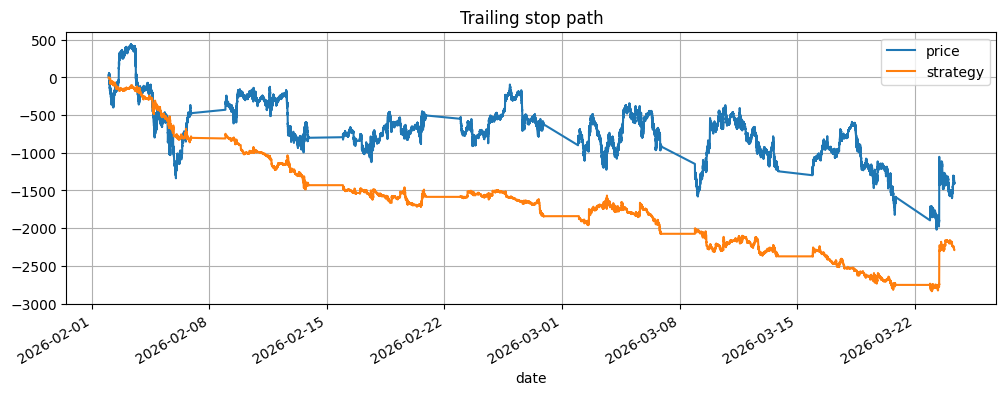

In [7]:
paths(results["trail"])[["price", "strategy"]].plot(
    figsize=(12, 4),
    grid=True,
    title="Trailing stop path",
)

In [8]:
results["trail"].positions.tail()

,date_o,open,date_c,close,g_pnl,pnl,duration
1671,2026-03-24 05:29:00+00:00,-24197.25,2026-03-24 05:34:00+00:00,24219.700,-22.450,-22.950,0 days 00:05:00
1672,2026-03-24 05:42:30+00:00,24261.50,2026-03-24 05:44:00+00:00,-24253.025,-8.475,-8.975,0 days 00:01:30
1673,2026-03-24 07:38:30+00:00,-24444.25,2026-03-24 07:44:30+00:00,24462.825,-18.575,-19.075,0 days 00:06:00
1674,2026-03-24 07:58:00+00:00,24465.50,2026-03-24 08:00:00+00:00,-24455.950,-9.550,-10.050,0 days 00:02:00
1675,2026-03-24 08:21:00+00:00,-24412.25,2026-03-24 08:23:30+00:00,24433.575,-21.325,-21.825,0 days 00:02:30
